# Confidence intervals — MKID (TiN), heavy mediator (F_DM = 1), m_DM = 10 MeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='TiN', q='0', mass='1', nbins=5`, background `none`
- Outputs per model: `results/MKID/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'TiN', '0', '1', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


RunConfig(material='TiN', q='0', mass='1', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
counts per bin: [1359.1 4052.3 5883.5 7554.  9026.4]
[1/24] idx 0 (v=57 km/s)  best 4.01e-26 cm^-1  1sigma [3.94e-26, 6.76e-24]  2sigma [3.84e-26, 1.38e-23]  (38 evals)
[2/24] idx 1 (v=57 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 1.69e-24]  2sigma [3.79e-26, 3.27e-24]  (33 evals)
[3/24] idx 2 (v=58 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 6.9e-25]  2sigma [3.79e-26, 1.31e-24]  (31 evals)
[4/24] idx 3 (v=59 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 3.83e-25]  2sigma [3.79e-26, 6.82e-25]  (29 evals)
[5/24] idx 4 (v=60 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 2.3e-25]  2sigma [3.79e-26, 4.14e-25]  (30 evals)
[6/24] idx 5 (v=61 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 1.56e-25]  2sigma [3.79e-26, 2.71e-25]  (26 evals)
[7/24] idx 7 (v=62 km/s)  best 4.01e-26 cm^-1  1sigma [3.89e-26, 9.18e-26]  2sigma [3.79e-26, 1.34e-25]  (22 evals)
[8/24] idx 8 (v=63 km/s)

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,56.5,4.014870e-26,3.939362e-26,6.757012e-24,3.840787e-26,1.378130e-23,-2%,+16730%,38
1,1,57.3,4.014870e-26,3.889762e-26,1.685331e-24,3.792428e-26,3.267453e-24,-3%,+4098%,33
2,2,58.1,4.014870e-26,3.889762e-26,6.898089e-25,3.792428e-26,1.310119e-24,-3%,+1618%,31
3,3,58.9,4.014870e-26,3.889762e-26,3.832920e-25,3.792428e-26,6.821965e-25,-3%,+855%,29
4,4,59.7,4.014870e-26,3.889762e-26,2.301653e-25,3.792428e-26,4.142234e-25,-3%,+473%,30
5,5,60.5,4.014870e-26,3.889762e-26,1.555258e-25,3.792428e-26,2.707398e-25,-3%,+287%,26
6,7,62.1,4.014870e-26,3.889762e-26,9.178087e-26,3.792428e-26,1.342263e-25,-3%,+129%,22
7,8,62.9,4.014870e-26,3.889762e-26,7.446550e-26,3.792428e-26,1.131226e-25,-3%,+85%,22
8,10,64.5,4.014870e-26,3.889762e-26,5.984392e-26,3.792428e-26,8.009135e-26,-3%,+49%,21
9,12,66.1,4.014870e-26,3.889762e-26,5.205814e-26,3.792428e-26,6.457094e-26,-3%,+30%,21


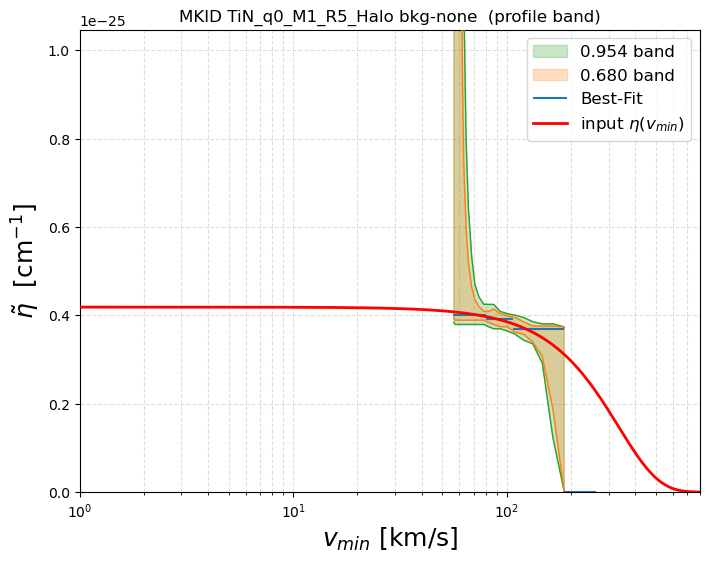

In [2]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='TiN', q='0', mass='1', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [1434.3 4213.3 5991.3 7538.8 8858.3]
[1/24] idx 0 (v=57 km/s)  best 4.23e-26 cm^-1  1sigma [4.15e-26, 9.71e-24]  2sigma [4.05e-26, 1.72e-23]  (37 evals)
[2/24] idx 1 (v=57 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 2.31e-24]  2sigma [3.95e-26, 3.63e-24]  (32 evals)
[3/24] idx 2 (v=58 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 9.4e-25]  2sigma [3.95e-26, 1.55e-24]  (31 evals)
[4/24] idx 3 (v=59 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 5.3e-25]  2sigma [3.95e-26, 8.59e-25]  (27 evals)
[5/24] idx 4 (v=60 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 3.03e-25]  2sigma [3.95e-26, 4.78e-25]  (25 evals)
[6/24] idx 5 (v=61 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 2.07e-25]  2sigma [3.95e-26, 3.15e-25]  (26 evals)
[7/24] idx 7 (v=62 km/s)  best 4.23e-26 cm^-1  1sigma [4.05e-26, 1.13e-25]  2sigma [3.95e-26, 1.63e-25]  (23 evals)
[8/24] idx 8 (v=63 km/s)

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,56.5,4.234611e-26,4.154970e-26,9.705741e-24,4.051000e-26,1.716552e-23,-2%,+22820%,37
1,1,57.3,4.234611e-26,4.051000e-26,2.308467e-24,3.949631e-26,3.631204e-24,-4%,+5351%,32
2,2,58.1,4.234611e-26,4.051000e-26,9.403805e-25,3.949631e-26,1.548740e-24,-4%,+2121%,31
3,3,58.9,4.234611e-26,4.051000e-26,5.304460e-25,3.949631e-26,8.585183e-25,-4%,+1153%,27
4,4,59.7,4.234611e-26,4.051000e-26,3.027965e-25,3.949631e-26,4.778081e-25,-4%,+615%,25
5,5,60.5,4.234611e-26,4.051000e-26,2.070453e-25,3.949631e-26,3.145281e-25,-4%,+389%,26
6,7,62.1,4.234611e-26,4.051000e-26,1.130559e-25,3.949631e-26,1.632586e-25,-4%,+167%,23
7,8,62.9,4.234611e-26,4.051000e-26,9.319350e-26,3.949631e-26,1.287385e-25,-4%,+120%,22
8,10,64.5,4.234611e-26,4.051000e-26,6.875704e-26,3.949631e-26,9.143898e-26,-4%,+62%,23
9,12,66.1,4.234611e-26,4.051000e-26,5.849853e-26,3.949631e-26,7.164577e-26,-4%,+38%,21


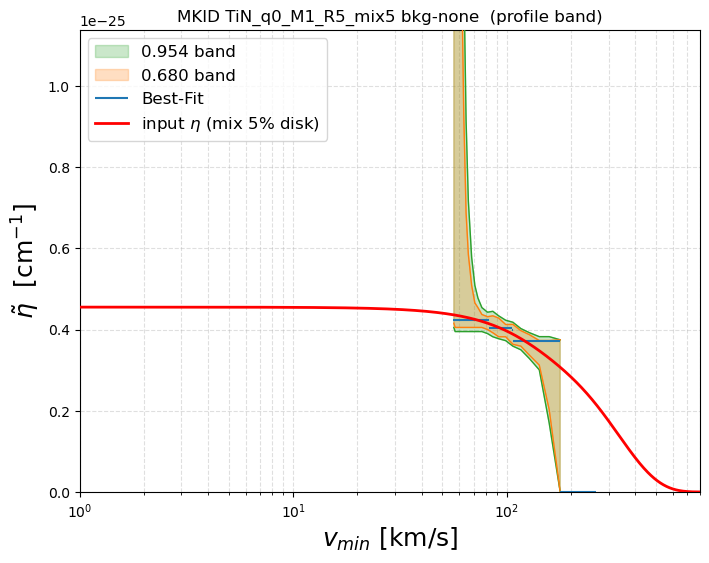

In [4]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


In [ ]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


29 points from /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/band


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,56.5,4.014870e-26,3.939362e-26,6.757012e-24,3.840787e-26,1.378130e-23,-2%,+16730%,38
1,1,57.3,4.014870e-26,3.889762e-26,1.685331e-24,3.792428e-26,3.267453e-24,-3%,+4098%,33
2,2,58.1,4.014870e-26,3.889762e-26,6.898089e-25,3.792428e-26,1.310119e-24,-3%,+1618%,31
3,3,58.9,4.014870e-26,3.889762e-26,3.832920e-25,3.792428e-26,6.821965e-25,-3%,+855%,29
4,4,59.7,4.014870e-26,3.889762e-26,2.301653e-25,3.792428e-26,4.142234e-25,-3%,+473%,30
5,5,60.5,4.014870e-26,3.889762e-26,1.555258e-25,3.792428e-26,2.707398e-25,-3%,+287%,26
6,7,62.1,4.014870e-26,3.889762e-26,9.178087e-26,3.792428e-26,1.342263e-25,-3%,+129%,22
7,8,62.9,4.014870e-26,3.889762e-26,7.446550e-26,3.792428e-26,1.131226e-25,-3%,+85%,22
8,9,63.7,4.014870e-26,3.889762e-26,6.622818e-26,3.792428e-26,8.976588e-26,-3%,+65%,20
9,10,64.5,4.014870e-26,3.889762e-26,5.984392e-26,3.792428e-26,8.009135e-26,-3%,+49%,21


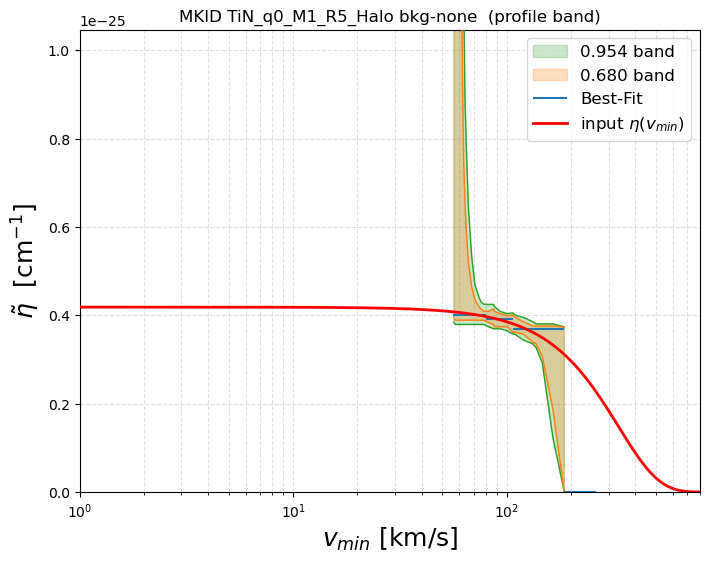

In [3]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
